In [2]:
from Tools.analysis_tools import *

In [3]:
# Percorso della cartella contenente i file CSV degli encoder
encoder_folder = "Encoder Analysis Data"

# Carica i dati
encoder_data = load_encoder_analysis_data(encoder_folder)

# Visualizza i dati caricati
print(encoder_data.head())


Caricando dati da: Encoder Analysis Data/2(Noise6)-1.csv
Caricando dati da: Encoder Analysis Data/3.csv
Caricando dati da: Encoder Analysis Data/2.csv
Caricando dati da: Encoder Analysis Data/1-1.csv
Caricando dati da: Encoder Analysis Data/1.csv
Caricando dati da: Encoder Analysis Data/2(NoNoise)-1.csv
Caricando dati da: Encoder Analysis Data/2-1.csv
Totale modelli caricati: 7
    Model Name  Latent Dim  Z2 R2 Mean  Z2 R2 Std  Z2 MSE Mean  Z2 MSE Std  \
0  2(Noise6)-1           5    0.565630   1.020516     0.012144    0.029196   
1            3           5    0.429792   0.256284     0.017217    0.007897   
2            2           5    0.506723   0.334932     0.014874    0.009369   
3          1-1           5    0.224878   0.240176     0.023421    0.007778   
4            1           5    0.558461   0.374550     0.013434    0.011545   

   Z2 MaxSE Mean  Z2 MaxSE Std  \
0       0.059437      0.082136   
1       0.106380      0.060282   
2       0.091623      0.051553   
3       0.1433

In [4]:
def plot_encoder_metric(data, metric, title, ylabel):
    """
    Crea un plot di una metrica (es. R2 Mean) per ogni encoder, utilizzando il nome del modello sull'asse X.
    
    Parametri:
    - data: DataFrame contenente i dati degli encoder.
    - metric: Nome della colonna nel DataFrame che rappresenta la metrica da plottare.
    - title: Titolo del grafico.
    - ylabel: Etichetta dell'asse Y.
    """
    # Converti i nomi dei modelli in stringhe per evitare errori di ordinamento
    data["Model Name"] = data["Model Name"].astype(str)
    
    # Ordina i modelli alfabeticamente per chiarezza (opzionale)
    data = data.sort_values(by="Model Name")

    # Estrai i nomi dei modelli e i valori della metrica
    model_names = data["Model Name"]
    metric_values = data[metric]
    
    # Crea il plot
    plt.figure(figsize=(12, 6))
    plt.bar(model_names, metric_values, color="skyblue", edgecolor="black")
    plt.title(title)
    plt.xlabel("Model Name")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


In [5]:
def plot_z2_metrics_per_encoder(data, r2_col, mse_col, maxse_col, title):
    """
    Crea un plot con barre sovrapposte per R2, MSE e MaxSE per ogni encoder.
    I valori sono normalizzati per gestire scale diverse.
    
    Parametri:
    - data: DataFrame con i dati degli encoder.
    - r2_col: Nome della colonna per R2.
    - mse_col: Nome della colonna per MSE.
    - maxse_col: Nome della colonna per MaxSE.
    - title: Titolo del grafico.
    """
    # Normalizza i dati per portare le metriche tra 0 e 1
    data["R2 Normalized"] = (data[r2_col] - data[r2_col].min()) / (data[r2_col].max() - data[r2_col].min())
    data["MSE Normalized"] = (data[mse_col] - data[mse_col].min()) / (data[mse_col].max() - data[mse_col].min())
    data["MaxSE Normalized"] = (data[maxse_col] - data[maxse_col].min()) / (data[maxse_col].max() - data[maxse_col].min())

    # Etichette sull'asse X
    model_names = data["Model Name"].astype(str)
    x = np.arange(len(model_names))
    
    # Larghezza delle barre
    bar_width = 0.3
    # Crea il plot
    plt.figure(figsize=(12, 6))
    
    # Aggiungi le barre per ciascuna metrica
    plt.bar(x - bar_width, data["R2 Normalized"], bar_width, alpha=0.7, label="R2 (Normalized)", color="blue")
    plt.bar(x, data["MSE Normalized"], bar_width, alpha=0.7, label="MSE (Normalized)", color="orange")
    plt.bar(x + bar_width, data["MaxSE Normalized"], bar_width, alpha=0.7, label="MaxSE (Normalized)", color="green")
    
    # Personalizza il grafico
    plt.title(title)
    plt.xlabel("Model Name")
    plt.ylabel("Normalized Metric Value")
    plt.xticks(x, model_names, rotation=45, ha="right", fontsize=10)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


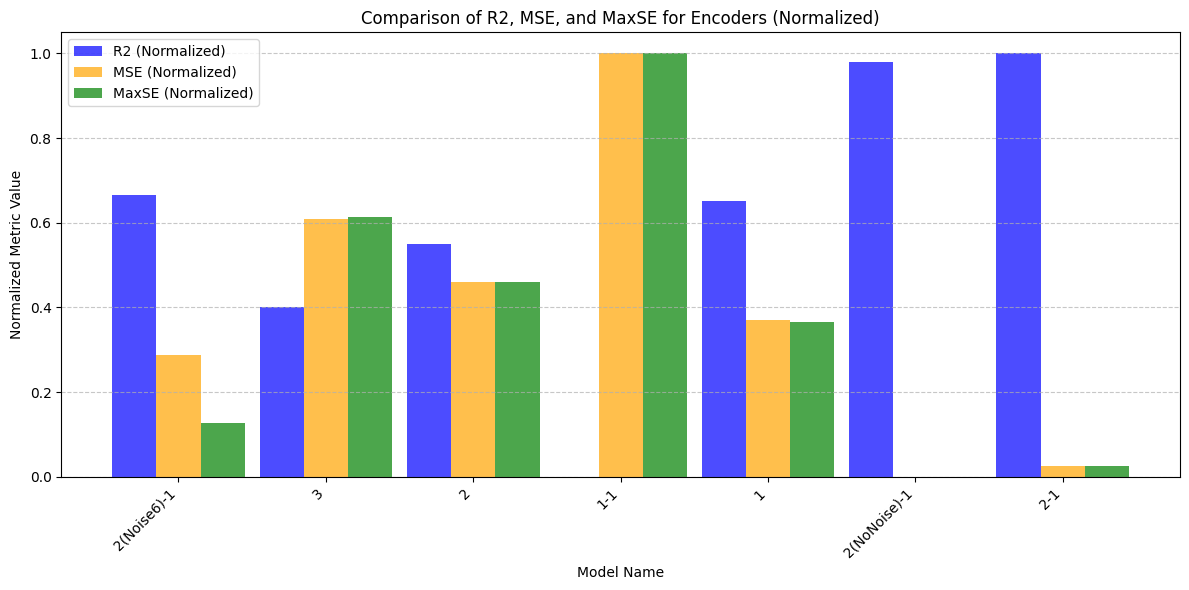

In [6]:
plot_z2_metrics_per_encoder(
    data=encoder_data, 
    r2_col="Z2 R2 Mean", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders (Normalized)"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!


[0.13577846 0.13265777 0.12187268 0.10258786 0.08691191 0.07730418
 0.07238242 0.05130273 0.04090326 0.03019931]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.13577846 0.13265777 0.12187268 0.10258786 0.08691191 0.07730418
 0.07238242 0.05130273 0.04090326 0.03019931]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]


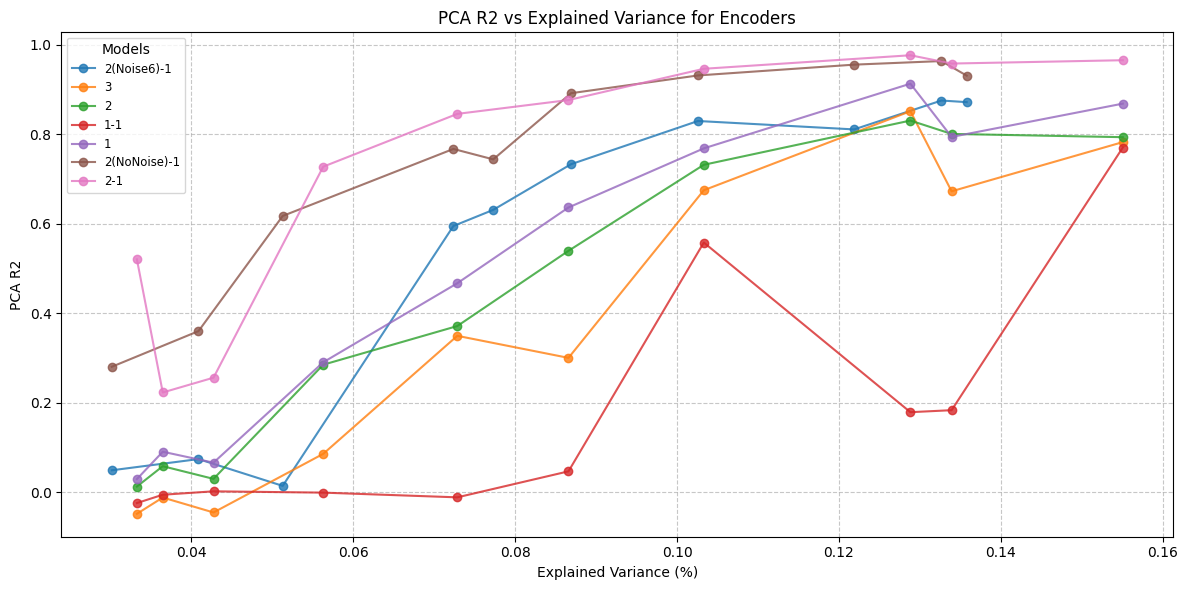

In [7]:
def preprocess_array_string(array_string):
    """
    Pre-processa una stringa di array per correggere problemi di formato,
    come spazi multipli, virgole extra e rimuovere caratteri indesiderati.
    """
    try:
        # Rimuove newline e spazi multipli
        clean_string = array_string.replace("\n", " ").replace("  ", " ").strip()
        # Sostituisce spazi con virgole
        clean_string = clean_string.replace(" ", ", ")
        # Rimuove eventuali virgole doppie create durante la pulizia
        clean_string = clean_string.replace(",,", ",")
        # Valuta la stringa come lista Python
        return eval(clean_string)
    except Exception as e:
        print(f"Errore nel preprocessamento della stringa: {array_string}")
        print(f"Dettagli dell'errore: {e}")
        return []


def plot_pca_r2_and_variance(data, r2_col, variance_col, title):
    """
    Crea un plot con linee collegate per ogni modello:
    - X: Varianza spiegata per ciascun componente principale.
    - Y: R2 per ciascun componente principale.
    
    Ogni modello ha un colore diverso.
    
    Parametri:
    - data: DataFrame con i dati degli encoder.
    - r2_col: Nome della colonna contenente i R2 per i PC.
    - variance_col: Nome della colonna contenente la varianza spiegata per i PC.
    - title: Titolo del grafico.
    """
    plt.figure(figsize=(12, 6))
    
    for index, row in data.iterrows():
        model_name = row["Model Name"]
        
        # Recupera R2 e varianza spiegata, correggendo eventuali problemi di formato
        r2_values = np.array(eval(row[r2_col]))
        variance_values = np.array(preprocess_array_string(row[variance_col]))
        
        # Plotta i valori per il modello
        plt.plot(
            variance_values, r2_values, marker='o', label=model_name, alpha=0.8
        )

        print(variance_values)
    
    # Personalizza il grafico
    plt.title(title)
    plt.xlabel("Explained Variance (%)")
    plt.ylabel("PCA R2")
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend(title="Models", loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

# Usa la funzione per creare il plot
plot_pca_r2_and_variance(
    data=encoder_data,
    r2_col="PCA R2 Z2 PC",
    variance_col="Varianzce Explained Z2",
    title="PCA R2 vs Explained Variance for Encoders"
)


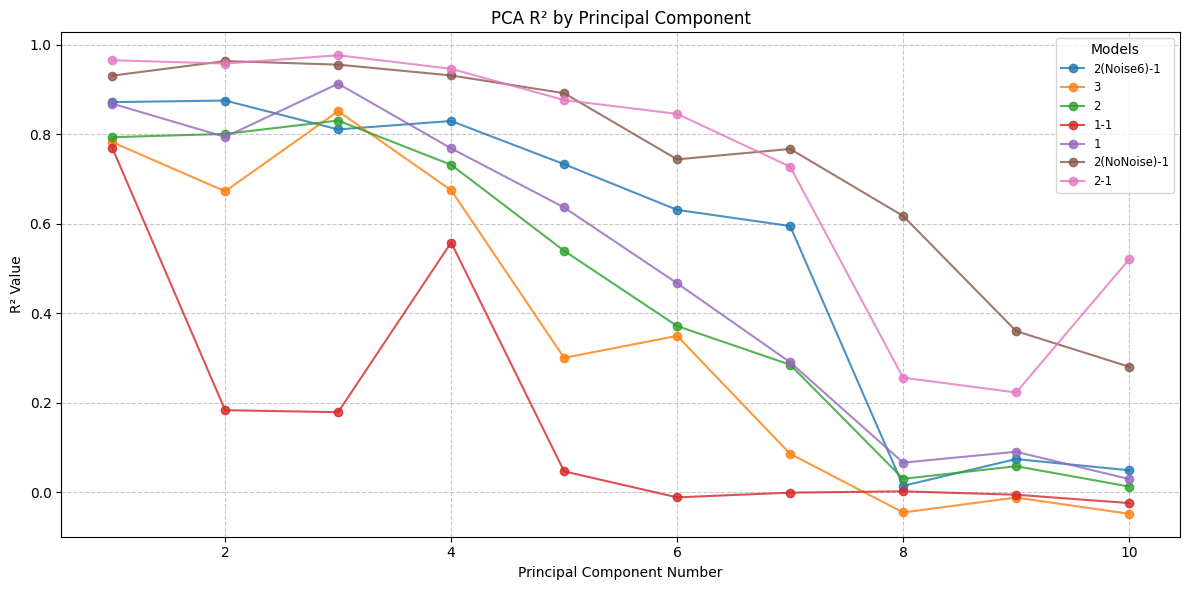

[0.13577846 0.13265777 0.12187268 0.10258786 0.08691191 0.07730418
 0.07238242 0.05130273 0.04090326 0.03019931]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]
[0.13577846 0.13265777 0.12187268 0.10258786 0.08691191 0.07730418
 0.07238242 0.05130273 0.04090326 0.03019931]
[0.15505533 0.13391227 0.12882373 0.10330974 0.08659596 0.07286661
 0.05630618 0.04275782 0.03649055 0.03329599]


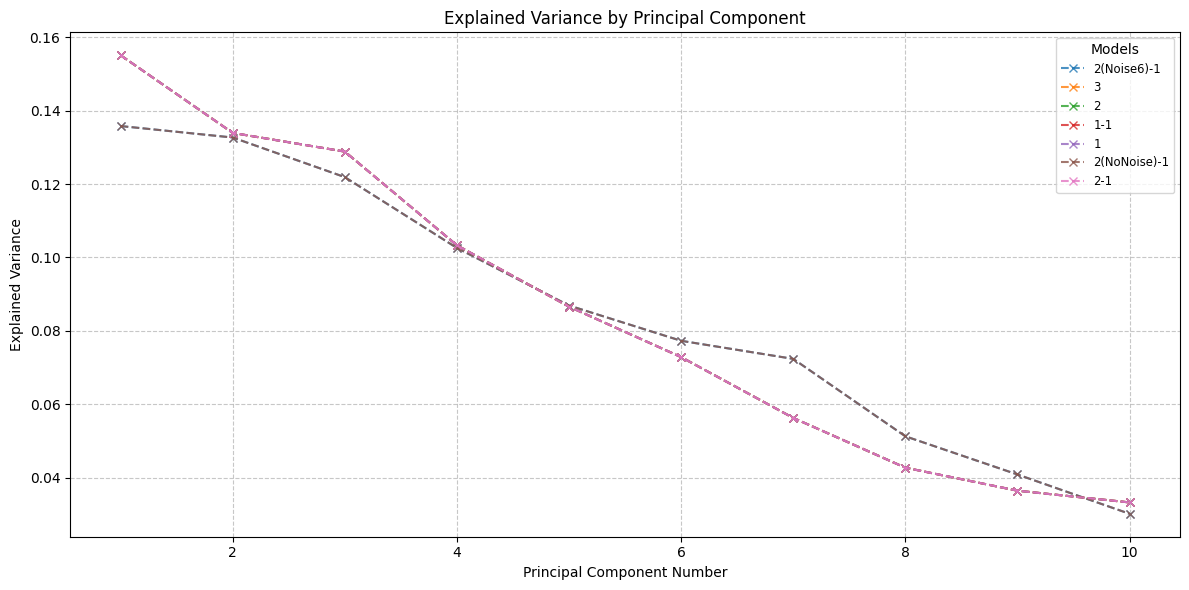

In [12]:
def preprocess_array_data(data, r2_col, variance_col):
    """
    Preprocessa i dati nelle colonne PCA R2 e Variance Explained.
    
    Parametri:
    - data: DataFrame con i dati.
    - r2_col: Nome della colonna con R2 delle componenti principali.
    - variance_col: Nome della colonna con la varianza spiegata.
    
    Ritorna:
    - Dizionario con i dati processati per plotting.
    """
    processed_data = {"models": [], "r2_values": [], "variance_values": []}

    for index, row in data.iterrows():
        model_name = row["Model Name"]

        # Trasforma i dati da stringa a lista numerica
        r2_values = np.array(preprocess_array_string(row[r2_col]))
        variance_values = np.array(preprocess_array_string(row[variance_col]))

        processed_data["models"].append(model_name)
        processed_data["r2_values"].append(r2_values)
        processed_data["variance_values"].append(variance_values)
    
    return processed_data


def plot_r2_and_variance_separate(data, r2_col, variance_col):
    """
    Crea due plot separati per R2 e Varianza spiegata dalle componenti principali.
    
    Parametri:
    - data: DataFrame con i dati.
    - r2_col: Nome della colonna con R2.
    - variance_col: Nome della colonna con la varianza spiegata.
    """
    processed_data = preprocess_array_data(data, r2_col, variance_col)
    
    # Plot per R2
    plt.figure(figsize=(12, 6))
    for model_name, r2_values in zip(processed_data["models"], processed_data["r2_values"]):
        components = np.arange(1, len(r2_values) + 1)
        plt.plot(components, r2_values, marker='o', linestyle='-', label=model_name, alpha=0.8)
    
    plt.title("PCA R² by Principal Component")
    plt.xlabel("Principal Component Number")
    plt.ylabel("R² Value")
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend(title="Models", loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

    # Plot per Varianza spiegata
    plt.figure(figsize=(12, 6))
    for model_name, variance_values in zip(processed_data["models"], processed_data["variance_values"]):
        components = np.arange(1, len(variance_values) + 1)
        plt.plot(components, variance_values, marker='x', linestyle='--', label=model_name, alpha=0.8)
        print(variance_values)
    
    plt.title("Explained Variance by Principal Component")
    plt.xlabel("Principal Component Number")
    plt.ylabel("Explained Variance")
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend(title="Models", loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()


# Chiamata alla funzione
plot_r2_and_variance_separate(
    data=encoder_data, 
    r2_col="PCA R2 Z2 PC", 
    variance_col="Varianzce Explained Z2"
)
